In [2]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langchain_community tavily-python

In [85]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [87]:
api_key = os.getenv("OPENAI_API_KEY")


In [5]:
#setting up chatmodels
from langchain_openai import ChatOpenAI
gpt4o_chat = ChatOpenAI(model="gpt-4o", temperature=0, openai_api_key=api_key)
gpt35_chat = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)

In [6]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class Mystate(TypedDict):
    messages: Annotated[list,add_messages]

def chat_node(state:Mystate)->Mystate:
    return {"messages": [gpt4o_chat.invoke(state['messages'])]}




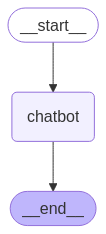

In [8]:
#graph
graph_builder = StateGraph(Mystate)
graph_builder.add_node("chatbot", chat_node)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [9]:
#invoking via streaming
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

User:  what is computer science?


Assistant: Computer science is the study of computers and computational systems. It encompasses a wide range of topics related to the design, development, and application of software and hardware. Key areas within computer science include:

1. **Algorithms and Data Structures**: The study of efficient methods for organizing and processing data.

2. **Programming Languages**: The design and implementation of languages that allow humans to communicate instructions to computers.

3. **Software Engineering**: The application of engineering principles to software development in a methodical way.

4. **Computer Architecture**: The design and organization of computer hardware components.

5. **Operating Systems**: The study of systems that manage computer hardware and software resources.

6. **Databases**: The design and management of systems that store and retrieve large amounts of data.

7. **Artificial Intelligence and Machine Learning**: The development of algorithms that allow computers 

User:  add 2 and 7


Assistant: 2 plus 7 equals 9.


User:  add above output to 4


Assistant: It seems like you're referring to a previous output or result, but I don't have access to prior interactions or outputs in this context. Could you please provide the specific number or result you want to add 4 to?


User:  


Assistant: Hello! How can I assist you today?


User:  q


Goodbye!


#### ADDING WEB TOOLS TO ABOVE CHATBOT ####


In [9]:
%%capture --no-stderr
%pip install -U tavily-python langchain_community

In [10]:
_set_env("TAVILY_API_KEY")

TAVILY_API_KEY:  ········


In [29]:
from langchain_community.tools import TavilySearchResults

tool = TavilySearchResults(
    max_results=1,
    include_answer=True,
    include_raw_content=False,
    include_images=False,
    # search_depth="advanced",
    # include_domains = [],
    # exclude_domains = []
)

tool.invoke({"query":"what is a node in langgrpah?"})

[{'title': 'A Comprehensive Guide About Langgraph: Code Included - Ionio',
  'url': 'https://www.ionio.ai/blog/a-comprehensive-guide-about-langgraph-code-included',
  'content': 'Now let’s take a look at each component of langgraph in detail 🚀\nNodes\nA node can be any function or tool your agent uses in langgraph and these nodes are connected with other nodes using edges. Every workflow ends with a “END” node in langgraph which shows the end of workflow. You also need to define a starting node which will be the starting point of your workflow. Optionally, you can also define an ending node if you know the ending point of your workflow.',
  'score': 0.8893851}]

In [30]:
tools = [tool]
llm_with_tools = gpt4o_chat.bind_tools(tools)

In [32]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage
sys_msg = SystemMessage(content="You are a helpful assistant with access to web search. If a question asks about factual or current knowledge, or things not stored in memory, use the `tavily_search_results` tool.Do NOT guess answers without verifying them.")

def assistant(state: Mystate):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

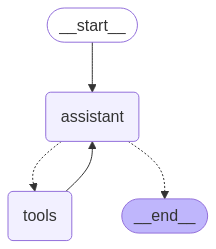

In [33]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
graph_builder = StateGraph(Mystate)
graph_builder.add_node("assistant", assistant)
graph_builder.add_node("tools", ToolNode(tools))
graph_builder.add_edge(START, "assistant")
graph_builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
graph_builder.add_edge("tools", "assistant")
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
messages = [HumanMessage(content="Who is the current president and vice president of USA?")]
messages = graph.invoke({"messages": messages})

In [35]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Who is the current president and vice president of USA?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_zuHbgjLOBQDD7cFWN84DuPon)
 Call ID: call_zuHbgjLOBQDD7cFWN84DuPon
  Args:
    query: current president of USA 2023
  tavily_search_results_json (call_mudrYbe0VkWcgczP8NubFfVj)
 Call ID: call_mudrYbe0VkWcgczP8NubFfVj
  Args:
    query: current vice president of USA 2023
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The White House - Joe Biden: The President", "url": "https://bidenwhitehouse.archives.gov/administration/president-biden/", "content": "President Joe Biden talks on the phone with Prime Minister Narendra Modi of India, Tuesday, February 14, 2023, in the Oval Office. (Official White House Photo by Adam Schultz)\nPresident Biden accompli

##### ADDING MEMORY #######


In [1]:
from langgraph.checkpoint.memory import MemorySaver

In [22]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition



memory = MemorySaver()

In [26]:
tool = TavilySearchResults(max_results=2)
tools = [tool]
llm_with_tool = gpt4o_chat.bind_tools(tools)
class Mystate(TypedDict):
    messages : Annotated[list, add_messages]

def chatbot(state : Mystate) -> Mystate:
    return {"messages" : [llm_with_tool.invoke(state['messages'])]}

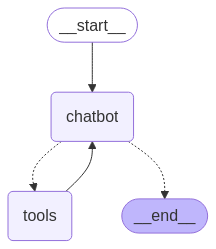

In [27]:

graph_builder = StateGraph(Mystate)
graph_builder.add_node("chatbot", chatbot)
tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge("tools","chatbot")

graph = graph_builder.compile(checkpointer = memory)
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [28]:
config = {"configurable": {"thread_id": "1"}}

user_input = "Hi!, My name is Glenn"

events = graph.stream(
    {"messages" : [{'role' : 'user', "content": user_input}]},
    config,
    stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()


================================ Human Message =================================

Hi!, My name is Glenn
================================== Ai Message ==================================

Hello, Glenn! How can I assist you today?


In [29]:
config = {"configurable": {"thread_id": "1"}}

user_input = "Do you remember my name?"

events = graph.stream(
    {"messages" : [{'role' : 'user', "content": user_input}]},
    config,
    stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Do you remember my name?
================================== Ai Message ==================================

Yes, you mentioned that your name is Glenn. How can I assist you further?


In [30]:
config = {"configurable": {"thread_id": "2"}}

user_input = "Do you remember my name?"

events = graph.stream(
    {"messages" : [{'role' : 'user', "content": user_input}]},
    config,
    stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Do you remember my name?
================================== Ai Message ==================================

I'm sorry, but I don't have access to personal data about users unless it has been shared with me in the course of our conversation. Therefore, I don't know your name. If you'd like, you can tell me your name!


In [31]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Do you remember my name?', additional_kwargs={}, response_metadata={}, id='3d53e982-bbe8-4b81-8f1f-9ba465e29a1d'), AIMessage(content="I'm sorry, but I don't have access to personal data about users unless it has been shared with me in the course of our conversation. Therefore, I don't know your name. If you'd like, you can tell me your name!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 85, 'total_tokens': 133, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_898ac29719', 'id': 'chatcmpl-BKBOHpsKGQRfs5xmbohRTycdpLpbZ', 'finish_reason': 'stop', 'logprobs': None}, id='run-f026b1b0-6b7f-445e-94c3-00a1dc6e018e-0', usage_metadata={'input_tokens': 85, '

In [32]:
snapshot.next

()

In [33]:
config = {"configurable": {"thread_id": "1"}}

user_input = "Do you remember my name?"

events = graph.stream(
    {"messages" : [{'role' : 'user', "content": user_input}]},
    config,
    stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Do you remember my name?
================================== Ai Message ==================================

Yes, your name is Glenn. How can I help you today?


In [34]:
config = {"configurable": {"thread_id": "1"}}

user_input = "i like to read, cook and good at playing chess."

events = graph.stream(
    {"messages" : [{'role' : 'user', "content": user_input}]},
    config,
    stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

i like to read, cook and good at playing chess.
================================== Ai Message ==================================

That's great, Glenn! Reading, cooking, and playing chess are all wonderful activities. Do you have any favorite books or authors? What do you enjoy cooking the most? And do you have a favorite chess opening or strategy?


In [35]:
config = {"configurable": {"thread_id": "1"}}

user_input = "What are my hobbies?"

events = graph.stream(
    {"messages" : [{'role' : 'user', "content": user_input}]},
    config,
    stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What are my hobbies?
================================== Ai Message ==================================

Your hobbies are reading, cooking, and playing chess.


##### MORE ABOUT MEMORY #####
#InMemoryStore#


In [64]:
#In memory store#
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.base import BaseStore

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig

In [65]:
import uuid
from langgraph.store.memory import InMemoryStore
in_memory_store = InMemoryStore()

In [66]:
user_id = "1"
key = str(uuid.uuid4())
values = {"value":"I like pizza"}
namespace = (user_id, "memories")
in_memory_store.put(namespace, key, values)

In [67]:
# in_memory_store.get("memories", key)
memories = in_memory_store.search(namespace)
memories

[Item(namespace=['1', 'memories'], key='264abd88-d2db-4f18-8417-28451d287b7f', value={'value': 'I like pizza'}, created_at='2025-04-10T16:24:41.164345+00:00', updated_at='2025-04-10T16:24:41.164350+00:00', score=None)]

In [68]:
memories[0].dict()

{'namespace': ['1', 'memories'],
 'key': '264abd88-d2db-4f18-8417-28451d287b7f',
 'value': {'value': 'I like pizza'},
 'created_at': '2025-04-10T16:24:41.164345+00:00',
 'updated_at': '2025-04-10T16:24:41.164350+00:00',
 'score': None}

In [69]:
# The key, value
print(memories[0].key, memories[0].value)

264abd88-d2db-4f18-8417-28451d287b7f {'value': 'I like pizza'}


In [70]:
# Get the memory by namespace and key
memory = in_memory_store.get(namespace, key)
memory.dict()

{'namespace': ['1', 'memories'],
 'key': '264abd88-d2db-4f18-8417-28451d287b7f',
 'value': {'value': 'I like pizza'},
 'created_at': '2025-04-10T16:24:41.164345+00:00',
 'updated_at': '2025-04-10T16:24:41.164350+00:00'}

In [71]:
memory.namespace

('1', 'memories')

In [72]:
type(memories)

list

In [73]:
# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """You are a helpful assistant with memory that provides information about the user. 
If you have memory for this user, use it to personalize your responses.
Here is the memory (it may be empty): {memory}"""

# Create new memory from the chat history and any existing memory
CREATE_MEMORY_INSTRUCTION = """"You are collecting information about the user to personalize your responses.

CURRENT USER INFORMATION:
{memory}

INSTRUCTIONS:
1. Review the chat history below carefully
2. Identify new information about the user, such as:
   - Personal details (name, location)
   - Preferences (likes, dislikes)
   - Interests and hobbies
   - Past experiences
   - Goals or future plans
3. Merge any new information with existing memory
4. Format the memory as a clear, bulleted list
5. If new information conflicts with existing memory, keep the most recent version

Remember: Only include factual information directly stated by the user. Do not make assumptions or inferences.

Based on the chat history below, please update the user information:"""

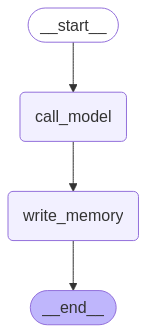

In [77]:
def call_model(state: MessagesState, config : RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")
    if existing_memory:
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found."
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=existing_memory_content)
    
    # Respond using memory as well as the chat history
    response = model.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}


def write_memory(state: MessagesState, config : RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")
    if existing_memory:
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found."
    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=existing_memory_content)
    new_memory = model.invoke([SystemMessage(content=system_msg)]+state['messages'])

    # Overwrite the existing memory in the store 
    key = "user_memory"

    # Write value as a dictionary with a memory key
    store.put(namespace, key, {"memory": new_memory.content})

builder = StateGraph(MessagesState)
builder.add_node("call_model", call_memory)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# Compile the graph with the checkpointer fir and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [79]:
model = ChatOpenAI(model="gpt-4o", temperature=0) 

In [80]:
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="Hi, my name is Lance")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Lance
================================== Ai Message ==================================

Hello, Lance! Nice to meet you. How can I assist you today?


In [81]:
input_messages = [HumanMessage(content="I like to bike around San Francisco")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

That sounds like a great way to explore the city! San Francisco has some beautiful routes and views. Do you have a favorite biking trail or area in the city?


In [82]:
thread = {"configurable": {"thread_id": "1"}}
state = graph.get_state(thread).values
for m in state["messages"]: 
    m.pretty_print()

================================ Human Message =================================

Hi, my name is Lance
================================ Human Message =================================

Hi, my name is Lance
================================== Ai Message ==================================

Hello, Lance! Nice to meet you. How can I assist you today?
================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

That sounds like a great way to explore the city! San Francisco has some beautiful routes and views. Do you have a favorite biking trail or area in the city?


In [83]:
# Namespace for the memory to save
user_id = "1"
namespace = ("memory", user_id)
existing_memory = across_thread_memory.get(namespace, "user_memory")
existing_memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_memory',
 'value': {'memory': "**Updated User Information:**\n- User's name is Lance.\n- Likes to bike around San Francisco."},
 'created_at': '2025-04-10T16:53:12.181599+00:00',
 'updated_at': '2025-04-10T16:53:12.181614+00:00'}

In [84]:
# We supply a user ID for across-thread memory as well as a new thread ID
config = {"configurable": {"thread_id": "2", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="Hi! Where would you recommend that I go biking?")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi! Where would you recommend that I go biking?
================================== Ai Message ==================================

Hi Lance! Biking around San Francisco offers some fantastic routes. Here are a few recommendations:

1. **Golden Gate Park**: This is a classic choice with plenty of trails and beautiful scenery. You can enjoy the lush greenery and even stop by the Conservatory of Flowers or the de Young Museum.

2. **The Embarcadero**: Starting from AT&T Park, you can bike along the waterfront, passing the Ferry Building and continuing towards Fisherman's Wharf. It's a great way to enjoy the bay views.

3. **Marin Headlands**: If you're up for a bit of a challenge, you can cross the Golden Gate Bridge and explore the Marin Headlands. The views of the city and the ocean are breathtaking.

4. **Presidio**: This area offers a mix of forested trails and coastal views. You can explore the historic 

# TRUSTCALL #